## Handwritten Digit Recognition - MNIST Dataset - MLP(Multilayer Perceptron) - Python/Keras

#### Key Design Considerations

This is a Multi-Class Classification problem (10 classes)
- Language: Python
- Deep Learning Package: Keras
- Dataset: MNIST dataset available with Keras
- Model: MLP

#### Key Results
**MLP based solution**
- Input (784x1 column vector) -> 1 hidden layer (512 neurons, relu) -> Output (10 classes, softmax)
- Number of parameters = **407050**
- Training Accuracy = **~98.9%**
- Test Accuracy = **~98.0%**


#### Load Dataset

Load train and test datasets

In [1]:
from keras.datasets import mnist

In [2]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_images.shape

(60000, 28, 28)

In [4]:
train_labels.shape

(60000,)

In [5]:
test_images.shape

(10000, 28, 28)

In [6]:
test_labels.shape

(10000,)

We have following with us:

<br>**Training Set**
- 60000 images
- Each image is of the shape 28 x 28 (rows x columns)
- 60000 labels defining the digit that corresponds to the respective image

<br>**Test Set**
- 10000 images
- Each image is of the shape 28 x 28 (rows x columns)
- 10000 labels defining the digit that corresponds to the respective image

#### Dataset Visualization

Let us visualize the handwritten digit images and labels for 0th training sample. We can see that the 0th image shows a handwritten 5 and the 0th label has the value 5.

In [10]:
import matplotlib.pyplot as plt

In [11]:
# running this once shows the plts in gray scale as default
# https://stackoverflow.com/questions/3823752/display-image-as-grayscale-using-matplotlib
plt.gray()

<Figure size 640x480 with 0 Axes>

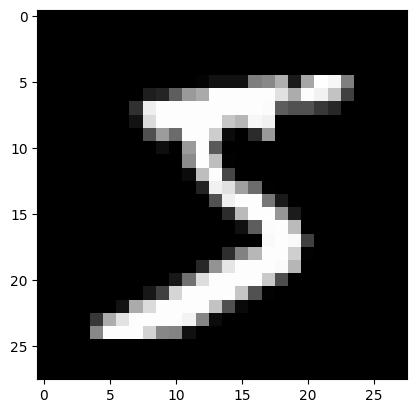

In [12]:
# if we do run the plt.gray() ... below code would have shown a color image
plt.imshow(train_images[0])

In [13]:
train_labels[0]

np.uint8(5)

### MLP based solution

#### Define the model
- Input Shape: Column Vector corresponding to 28x28 image matrix for the digit = 784 rows,1 column = 784,1
- 1st hidden layer: Number of neurons = 512
- 1st hidden layer: Activation Function = relu (for non-linearity detection)
- Output layer: Number of neurons = 10 (corresponding to 0 to 9 digits)
- Output layer: Activation Function = softmax (to get probabilities for the repective 10 classes)

In [7]:
from keras import models

In [8]:
from keras import layers

In [9]:
model_mlp = models.Sequential()

In [10]:
model_mlp.add(layers.Dense(512, activation='relu', input_shape=(28*28,)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model_mlp.add(layers.Dense(10, activation='softmax'))

In [12]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

#### Define the optimizer function, loss function and metrics to be used for the model.
- Going ahead with the well known functions at this point in time
- Selected accuracy as the metrics to understand validation / test accuracy of the model

In [13]:
model_mlp.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

#### We will preprocess the data before feeding it to the model:
- Change the images to column vector form: 28x28 -> 784x1 to match to model's input expectations
- Change the vector values from int to float: to get continuos values as we move thro's model's layers
- Scale the vector values to be in the [0,1] interval: model will see all samples with equal weightage as the range of values for all samples are same.

Note: gray scale values will be from 0 to 255... hence dividing the float by 255 will give us the values in [0,1] interval

#### Data Preprocessing - Train Images

In [14]:
train_images.shape

(60000, 28, 28)

In [15]:
train_images_mlp = train_images.reshape(60000, 28*28)

In [16]:
train_images_mlp.shape

(60000, 784)

In [17]:
# type is an int
# chose a non-zero value element ... somewhere in the middle of the column vector
type(train_images_mlp[0][350])

numpy.uint8

In [18]:
train_images_mlp[0][350]

np.uint8(70)

In [19]:
train_images_mlp = train_images_mlp.astype('float32') / 255

In [20]:
# type has changed to float
type(train_images_mlp[0][350])

numpy.float32

In [21]:
train_images_mlp[0][350]

np.float32(0.27450982)

In [22]:
70/255

0.27450980392156865

#### Data Preprocessing - Test Images

In [23]:
test_images_mlp = test_images.reshape(10000,28*28)

In [24]:
test_images_mlp = test_images_mlp.astype('float32') / 255

#### We will process the data labels:
- We have ten output classes ... consider it as a 10bit output
- We need to represent the label as a 10bit value where bit corresponding to the digit value will be 1 and rest all 9 bits will be 0
- Say label = 5. We will change it to a 10bit value as 0000010000 (note as the index starts at 0, 6th element corresponds to digit 5 and hence is 1 and rest are zero)

#### Data Preprocessing - Train Labels

In [25]:
train_labels[0]

np.uint8(5)

In [26]:
from keras.utils import to_categorical

In [27]:
train_labels_mlp = to_categorical(train_labels)

In [28]:
train_labels_mlp[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

#### Data Preprocessing - Train Labels

In [29]:
test_labels_mlp = to_categorical(test_labels)

#### Train the Model

We will now train the model using train images and train labels.
- We will use a batch size = 120.
- 1 epoch = 60000 / 120 = 500 batches
- 1 epoch = 1 complete run of all train samples for training the model
- We will go for a total of 5 epochs = 5 complete run of the all train samples

In [30]:
model_mlp.fit(train_images_mlp, train_labels_mlp, epochs = 5, batch_size = 120)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9259 - loss: 0.2559
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9693 - loss: 0.1041
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9801 - loss: 0.0688
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9849 - loss: 0.0498
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9892 - loss: 0.0368


At this run, we got a training accuracy of **~98.9%**

#### Test the Model

We will now test model's performance with the test data.
- We predict the class for each of the 10000 test using the model.
- We will check the test accuracy.

In [31]:
test_loss_mlp, test_acc_mlp = model_mlp.evaluate(test_images_mlp, test_labels_mlp)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9790 - loss: 0.0636


In [33]:
print('test accuracy:', (test_acc_mlp*100))

test accuracy: 97.89999723434448


At this run, we got a training accuracy of **~98.0%**

In [34]:
import tensorflow as tf

In [35]:
# Convert Model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_mlp)
tfmodel = converter.convert()
open("digit_recognition.tflite","wb").write(tfmodel)

Saved artifact at '/tmp/tmp5vgimde2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136988187877712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136988187878864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136988187876176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136988187879056: TensorSpec(shape=(), dtype=tf.resource, name=None)


1629924

In [36]:
from google.colab import files

files.download("digit_recognition.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# Convert Model to TFLite and Apply Quantization
converter1 = tf.lite.TFLiteConverter.from_keras_model(model_mlp)
converter1.optimizations = [tf.lite.Optimize.DEFAULT]
tfmodel1 = converter1.convert()
open("digit_recognition_quant.tflite","wb").write(tfmodel1)

Saved artifact at '/tmp/tmpj0xayj3g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136988187877712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136988187878864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136988187876176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136988187879056: TensorSpec(shape=(), dtype=tf.resource, name=None)


416664

In [38]:


from google.colab import files

files.download("digit_recognition_quant.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>